# testing

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
from scipy import stats

In [4]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 2.0
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [5]:
# plt.style.use('dark_background')

### Functions needed for the analysis

In [6]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
import matplotlib.patches as mpatches

def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
        
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = 'horizontal', shrink=0.4, aspect = 20, pad = 0.05, label = cbar_label)

In [7]:
from functions import preproc_funcs as funcs

In [8]:
from functions import xr_lowess

In [9]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    x = x.copy()
    res = STL(x, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

In [11]:
ts_2030 = xr.open_mfdataset('/scratch/p66/ars599/ACCESS_output/APP_output/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i1p1f2/Amon/ts/gn/v20250307/*.nc')

In [17]:
ts_2030_ann = ts_2030.ts.resample(time = 'AS-JUN').mean('time')

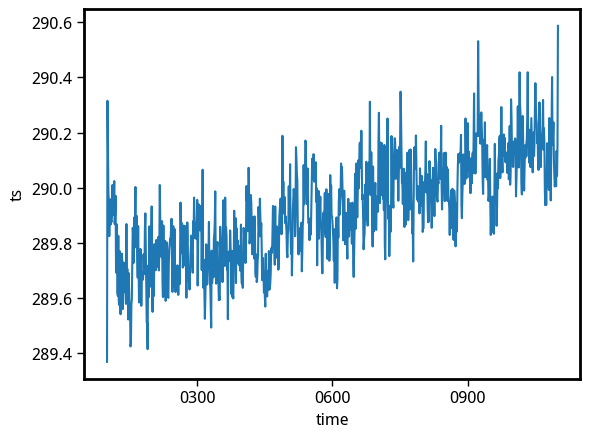

In [18]:
weights= np.cos(np.deg2rad(ts_2030_ann.lat))
ts_2030_ann.weighted(weights).mean(('lat', 'lon')).plot()

In [ ]:
ts5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5.nc')
ts5_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5_ext.nc')

psl5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5.nc')
psl5_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5_ext.nc')

: 

In [12]:
# out5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp5_over.nc')
# out5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/out_ssp5_over_extensions.nc')

# psl5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/psl_ssp5_over.nc')
# psl5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/psl_ssp5_over_extensions.nc')

In [13]:
ts3 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp3.nc')
psl3 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp3.nc')

In [14]:
ts2 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp2.nc')
psl2 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp2.nc')

In [15]:
ts1 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp1.nc')
ts1_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp1_ext.nc')
psl1 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp1.nc')
psl1_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp1_ext.nc')

In [16]:
# ts5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5o.nc')
ts5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/ts_ssp5o_ext.nc')
# psl5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5o.nc')
psl5o_ext = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/CMIP6_models/psl_ssp5o_ext.nc')

In [17]:
xx, yy = np.meshgrid(ts5.lon, ts5.lat)

In [18]:
weights = np.cos(np.deg2rad(ts5.lat))
weights.name='weights'
weights

<xarray.DataArray 'weights' (lat: 120)>
array([0.0130896 , 0.03925982, 0.06540313, 0.09150162, 0.1175374 ,
       0.14349262, 0.1693495 , 0.19509032, 0.22069744, 0.24615329,
       0.27144045, 0.29654157, 0.32143947, 0.34611706, 0.37055744,
       0.39474386, 0.41865974, 0.44228869, 0.46561452, 0.48862124,
       0.51129309, 0.53361452, 0.55557023, 0.57714519, 0.5983246 ,
       0.61909395, 0.639439  , 0.65934582, 0.67880075, 0.69779046,
       0.71630194, 0.73432251, 0.75183981, 0.76884183, 0.78531693,
       0.80125381, 0.81664156, 0.83146961, 0.84572782, 0.85940641,
       0.87249601, 0.88498764, 0.89687274, 0.90814317, 0.91879121,
       0.92880955, 0.93819134, 0.94693013, 0.95501994, 0.96245524,
       0.96923091, 0.97534232, 0.98078528, 0.98555606, 0.98965139,
       0.99306846, 0.99580493, 0.99785892, 0.99922904, 0.99991433,
       0.99991433, 0.99922904, 0.99785892, 0.99580493, 0.99306846,
       0.98965139, 0.98555606, 0.98078528, 0.97534232, 0.96923091,
       0.96245524, 0.95501994, 0.94693013, 0.93819134, 0.92880955,
       0.91879121, 0.90814317, 0.89687274, 0.88498764, 0.87249601,
       0.85940641, 0.84572782, 0.83146961, 0.81664156, 0.80125381,
       0.78531693, 0.76884183, 0.75183981, 0.73432251, 0.71630194,
       0.69779046, 0.67880075, 0.65934582, 0.639439  , 0.61909395,
       0.5983246 , 0.57714519, 0.55557023, 0.53361452, 0.51129309,
       0.48862124, 0.46561452, 0.44228869, 0.41865974, 0.39474386,
       0.37055744, 0.34611706, 0.32143947, 0.29654157, 0.27144045,
       0.24615329, 0.22069744, 0.19509032, 0.1693495 , 0.14349262,
       0.1175374 , 0.09150162, 0.06540313, 0.03925982, 0.0130896 ])
Coordinates:
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [18]:
ts5['gmst'] = ts5.ts.weighted(weights).mean(('lat', 'lon'))
ts5['so_sst'] = ts5.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5['np_sst'] = ts5.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5['wp_sst'] = ts5.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts5['ep_sst'] = ts5.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = ts5.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# ts5['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')

In [19]:
psl5['wc_index'] = psl5.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl5.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [20]:
ts5_ext['gmst'] = ts5_ext.ts.weighted(weights).mean(('lat', 'lon'))
ts5_ext['so_sst'] = ts5_ext.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5_ext['np_sst'] = ts5_ext.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5_ext['wp_sst'] = ts5_ext.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts5_ext['ep_sst'] = ts5_ext.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = ts5_ext.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# ts5_ext['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')

In [21]:
psl5_ext['wc_index'] = psl5_ext.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl5_ext.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [22]:
ts3['gmst'] = ts3.ts.weighted(weights).mean(('lat', 'lon'))
ts3['so_sst'] = ts3.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts3['np_sst'] = ts3.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts3['wp_sst'] = ts3.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts3['ep_sst'] = ts3.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [23]:
psl3['wc_index'] = psl3.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl3.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [24]:
ts2['gmst'] = ts2.ts.weighted(weights).mean(('lat', 'lon'))
ts2['so_sst'] = ts2.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts2['np_sst'] = ts2.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts2['wp_sst'] = ts2.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts2['ep_sst'] = ts2.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [25]:
psl2['wc_index'] = psl2.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl2.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [26]:
ts1['gmst'] = ts1.ts.weighted(weights).mean(('lat', 'lon'))
ts1['so_sst'] = ts1.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1['np_sst'] = ts1.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1['wp_sst'] = ts1.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts1['ep_sst'] = ts1.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [27]:
psl1['wc_index'] = psl1.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl1.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [28]:
ts1_ext['gmst'] = ts1_ext.ts.weighted(weights).mean(('lat', 'lon'))
ts1_ext['so_sst'] = ts1_ext.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1_ext['np_sst'] = ts1_ext.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts1_ext['wp_sst'] = ts1_ext.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts1_ext['ep_sst'] = ts1_ext.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [29]:
psl1_ext['wc_index'] = psl1_ext.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl1_ext.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

In [30]:
ts5o_ext['gmst'] = ts5o_ext.ts.weighted(weights).mean(('lat', 'lon'))
ts5o_ext['so_sst'] = ts5o_ext.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5o_ext['np_sst'] = ts5o_ext.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
ts5o_ext['wp_sst'] = ts5o_ext.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
ts5o_ext['ep_sst'] = ts5o_ext.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))

In [31]:
psl5o_ext['wc_index'] = psl5o_ext.psl.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon')) - psl5o_ext.psl.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))

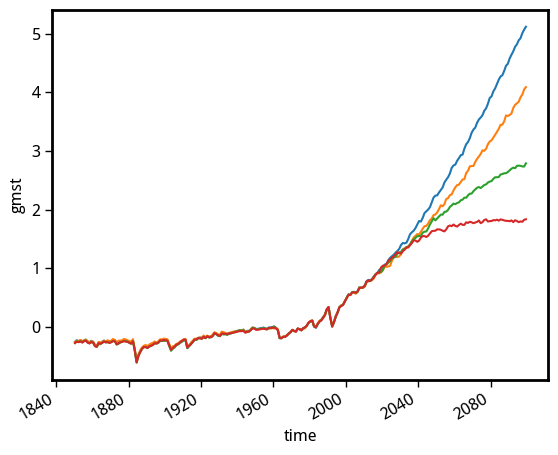

In [32]:
ts5.gmst.mean('model').plot()
ts3.gmst.mean('model').plot()
ts2.gmst.mean('model').plot()
ts1.gmst.mean('model').plot()

In [33]:
trans5 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5_ts.nc', use_cftime=True)
trans3 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp3_ts.nc', use_cftime=True)
trans2 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp2_ts.nc', use_cftime=True)
trans1 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp1_ts.nc', use_cftime=True)
trans5o = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/lens/ACCESS-ESM1-5_ssp5o_ts.nc', use_cftime=True)

In [34]:
stable = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable.nc', use_cftime=True)

In [35]:
trans5['gmst'] = trans5.ts.weighted(weights).mean(('lat', 'lon'))
trans5['so_sst'] = trans5.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
trans5['np_sst'] = trans5.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
trans5['wp_sst'] = trans5.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
trans5['ep_sst'] = trans5.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = trans5_ext.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# trans5_ext['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')

In [36]:
trans3['gmst'] = trans3.ts.weighted(weights).mean(('lat', 'lon'))
trans3['so_sst'] = trans3.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
trans3['np_sst'] = trans3.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
trans3['wp_sst'] = trans3.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
trans3['ep_sst'] = trans3.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = trans3_ext.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# trans3_ext['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')

In [37]:
trans2['gmst'] = trans2.ts.weighted(weights).mean(('lat', 'lon'))
trans2['so_sst'] = trans2.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
trans2['np_sst'] = trans2.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
trans2['wp_sst'] = trans2.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
trans2['ep_sst'] = trans2.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = trans2.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# trans2['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')


In [38]:
trans1['gmst'] = trans1.ts.weighted(weights).mean(('lat', 'lon'))
trans1['so_sst'] = trans1.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
trans1['np_sst'] = trans1.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
trans1['wp_sst'] = trans1.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
trans1['ep_sst'] = trans1.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = trans1.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# trans1['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')


In [39]:
trans5o['gmst'] = trans5o.ts.weighted(weights).mean(('lat', 'lon'))
trans5o['so_sst'] = trans5o.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
trans5o['np_sst'] = trans5o.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
trans5o['wp_sst'] = trans5o.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
trans5o['ep_sst'] = trans5o.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = trans5o.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# trans5o['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')


In [40]:

stable['gmst'] = stable.ts.weighted(weights).mean(('lat', 'lon'))
stable['so_sst'] = stable.ts.sel(lat = slice(-65,-45), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
stable['np_sst'] = stable.ts.sel(lat = slice(45,65), lon = slice(120,290)).weighted(weights).mean(('lat', 'lon'))
stable['wp_sst'] = stable.ts.sel(lat = slice(-5,5), lon = slice(140,170)).weighted(weights).mean(('lat', 'lon'))
stable['ep_sst'] = stable.ts.sel(lat = slice(-5,5), lon = slice(190,270)).weighted(weights).mean(('lat', 'lon'))
# test = stable.ts.sel(lat = slice(-5,5), lon = slice(-170+260,-120+360)).weighted(weights).mean(('lat', 'lon')).copy()
# stable['nino34'] = funcs.detrend_separate_check(test, period=15, dim='time')

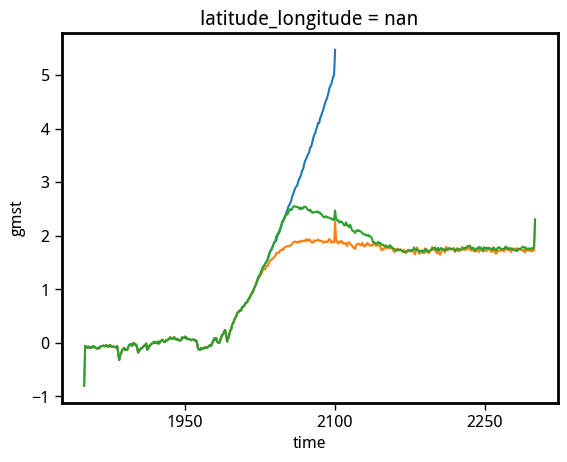

In [170]:
# trans5.gmst.mean('model').plot()
# trans3.gmst.mean('model').plot()
trans5.gmst.mean('model').sel(time = slice('1850', '2100')).plot()
trans1.gmst.mean('model').plot()
trans5o.gmst.mean('model').plot()
# stable.gmst.isel(model=0).plot()
# stable.gmst.isel(model=1).plot()
# stable.gmst.isel(model=2).plot()
# stable.gmst.isel(model=3).plot()
# stable.gmst.isel(model=4).plot()
# stable.gmst.isel(model=5).plot()
# stable.gmst.isel(model=6).plot()
# stable.gmst.sel(model='B2040').plot()

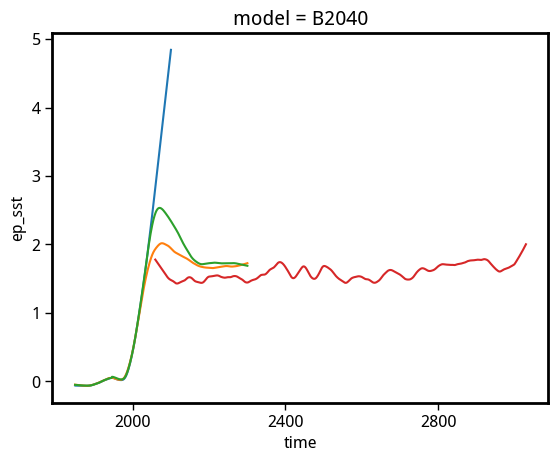

In [96]:
# trans5.ep_sst.mean('model').plot()
# trans3.ep_sst.mean('model').plot()
loess3d(trans5.ep_sst.sel(time = slice('1850', '2100')), dim='time', period=31).mean('model').plot()
loess3d(trans1.ep_sst, dim='time', period=31).mean('model').plot()
loess3d(trans5o.ep_sst, dim='time', period=31).mean('model').plot()
# stable.ep_sst.isel(model=0).plot()
# stable.ep_sst.isel(model=1).plot()
# stable.ep_sst.isel(model=2).plot()
# stable.ep_sst.isel(model=3).plot()
# stable.ep_sst.isel(model=4).plot()
# stable.ep_sst.isel(model=5).plot()
# stable.ep_sst.isel(model=6).plot()
loess3d(stable.ep_sst.dropna('time', how='any'), dim='time', period=31).sel(model='B2040').plot()

In [1]:
ax = plt.axes(projection=ccrs.Miller(central_longitude=180))
(trans1.sel(time = slice('1850', '1900'), model='ACCESS-ESM1-5_r10i1p1f1').ts.mean('time')).plot(vmin=-3, transform=ccrs.PlateCarree())
ax.coastlines()

NameError: name 'plt' is not defined

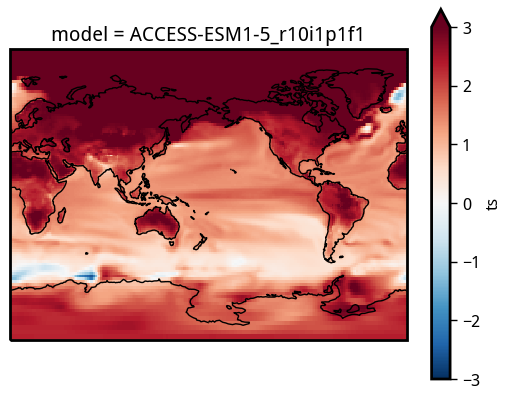

In [101]:
ax = plt.axes(projection=ccrs.Miller(central_longitude=180))
(trans1.sel(time = slice('2025', '2055'), model='ACCESS-ESM1-5_r10i1p1f1').ts.mean('time') - trans1.sel(time = slice('1850', '1900'), model='ACCESS-ESM1-5_r10i1p1f1').ts.mean('time')).plot(vmin=-3, transform=ccrs.PlateCarree())
ax.coastlines()

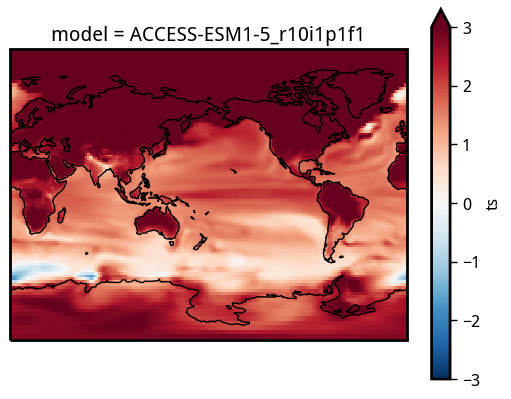

In [68]:
ax = plt.axes(projection=ccrs.Miller(central_longitude=180))
(trans5.sel(time = slice('2025', '2055'), model='ACCESS-ESM1-5_r10i1p1f1').ts.mean('time') - trans5.sel(time = slice('1850', '1900'), model='ACCESS-ESM1-5_r10i1p1f1').ts.mean('time')).plot(vmin=-3, transform=ccrs.PlateCarree())
ax.coastlines()

Text(0.5, 1.0, 'stabilised run B2040')

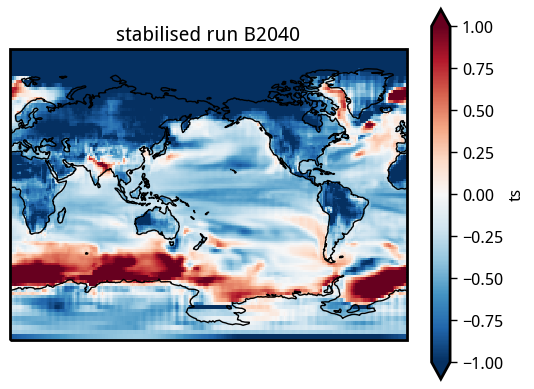

In [166]:
ax = plt.axes(projection=ccrs.Miller(central_longitude=180))
(stable.sel(time = slice('2270', '2300'), model='B2040').ts.mean('time') - trans5.sel(time = slice('2025', '2055'), model='ACCESS-ESM1-5_r10i1p1f1').ts.mean('time')).plot(vmin=-1, transform=ccrs.PlateCarree())
ax.coastlines()
plt.title('stabilised run B2040')

Text(0.5, 1.0, 'ACCESS_r10 ssp1_extension')

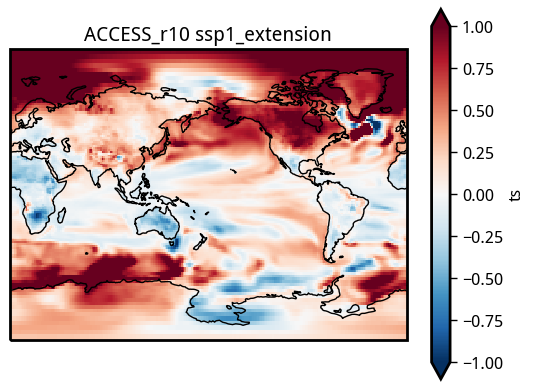

In [167]:
ax = plt.axes(projection=ccrs.Miller(central_longitude=180))
(trans1.sel(time = slice('2270', '2300'), model='ACCESS-ESM1-5_r10i1p1f1').ts.mean('time') - trans1.sel(time = slice('2025', '2055'), model='ACCESS-ESM1-5_r10i1p1f1').ts.mean('time')).plot(vmin=-1, transform=ccrs.PlateCarree())
ax.coastlines()
plt.title('ACCESS_r10 ssp1_extension')

KeyError: "not all values found in index 'model'. Try setting the `method` keyword argument (example: method='nearest')."

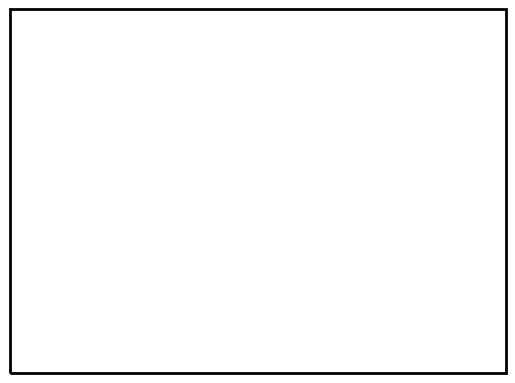

In [169]:
ax = plt.axes(projection=ccrs.Miller(central_longitude=180))
(trans5o.sel(time = slice('2270', '2300'), model='ACCESS-ESM1-5_r10i1p1f').ts.mean('time') - trans5.sel(time = slice('2025', '2055'), model='ACCESS-ESM1-5_r10i1p1f').ts.mean('time')).plot(vmin=-1, transform=ccrs.PlateCarree())
ax.coastlines()
plt.title('ACCESS_r10 ssp1_extension')

Text(0.5, 1.0, 'stabilised run B2040 2870-2900')

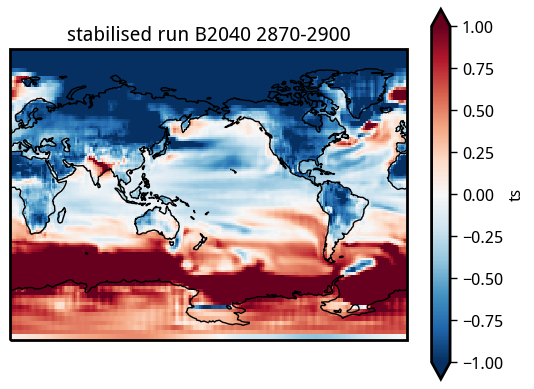

In [100]:
ax = plt.axes(projection=ccrs.Miller(central_longitude=180))
(stable.sel(time = slice('2870', '2900'), model='B2040').ts.mean('time') - trans5.sel(time = slice('2025', '2055'), model='ACCESS-ESM1-5_r10i1p1f1').ts.mean('time')).plot(vmin=-1, transform=ccrs.PlateCarree())
ax.coastlines()
plt.title('stabilised run B2040 2870-2900')

In [107]:
nino34_models = funcs.detrend_separate_check(ts5.ts.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).mean(('lat', 'lon')), dim='time', period=15)

In [120]:
skw20c = nino34_models.sel(time = slice('1900', '2000')).reduce(stats.skew, dim='time')
skw21c = nino34_models.sel(time = slice('2000', '2100')).reduce(stats.skew, dim='time')

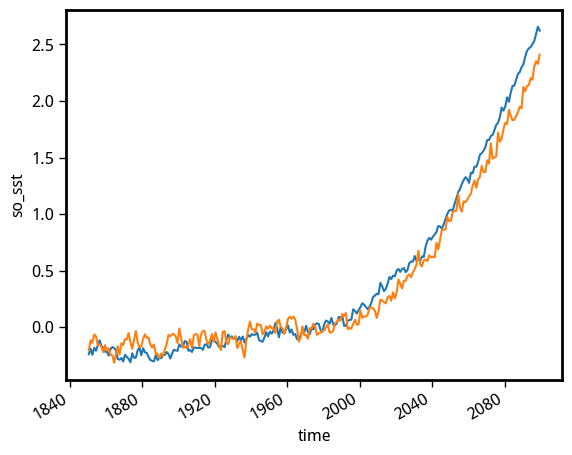

In [129]:
ts5.so_sst.where((skw21c - skw20c) < 0, drop=True).mean('model').plot()
ts5.so_sst.where((skw21c - skw20c) > 0, drop=True).mean('model').plot()

In [158]:
ep_neg = ts5.ep_sst.where((skw21c - skw20c) < 0, drop=True)
ep_pos = ts5.ep_sst.where((skw21c - skw20c) > 0, drop=True)

In [159]:
ep_neg

<xarray.DataArray 'ep_sst' (model: 36, time: 250)>
array([[-1.12682883, -0.36251486, -0.24540809, ...,  5.71904168,
         5.24127135,  6.10459914],
       [-1.12682883, -0.36251486, -0.24540809, ...,  5.71904168,
         5.24127135,  6.10459914],
       [-0.76600978, -0.47919981,  0.79875747, ...,  3.99952393,
         4.27827937,  2.84628306],
       ...,
       [-0.7389482 ,  1.94003028, -2.61031283, ...,  5.64884348,
         1.74822945,  3.88801729],
       [-1.22762146, -0.04873366, -0.0232177 , ...,  3.67714861,
         3.72519264,  4.37531737],
       [ 1.09761832, -2.00108957, -1.81745869, ...,  3.68759884,
         5.46219673,  3.73979497]])
Coordinates:
  * time     (time) datetime64[ns] 1850-06-01 1851-06-01 ... 2099-06-01
  * model    (model) object 'CanESM5' 'CanESM5-CanOE' ... 'CAS-ESM2-0'

{'whiskers': [<matplotlib.lines.Line2D at 0x7faa49329850>,
 'caps': [<matplotlib.lines.Line2D at 0x7faa49329df0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7faa49329580>,
 'medians': [<matplotlib.lines.Line2D at 0x7faa493383d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7faa493386a0>,
 'means': []}

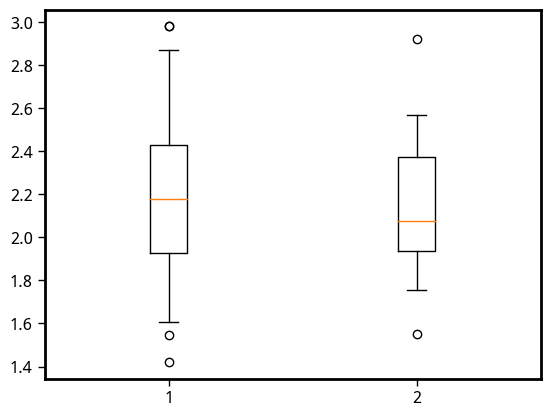

In [160]:
neg_change = ep_neg.sel(time = slice('2000', '2100')).mean('time') - ep_neg.sel(time = slice('1900', '2000')).mean('time')
pos_change = ep_pos.sel(time = slice('2000', '2100')).mean('time') - ep_pos.sel(time = slice('1900', '2000')).mean('time')
plt.boxplot([neg_change, pos_change], whis=[5,95])

In [148]:
pos_change

(<xarray.DataArray 'ep_sst' (model: 11)>
 array([2.95727614, 1.78019242, 1.3613869 , 2.54817776, 2.05026324,
        2.58329661, 1.88332429, 1.45877048, 2.05301202, 1.88762645,
        1.62344415])
 Coordinates:
   * model    (model) object 'E3SM-1-1' 'MPI-ESM1-2-HR' ... 'BCC-CSM2-MR',)

In [149]:
neg_change

(<xarray.DataArray 'ep_sst' (model: 36)>
 array([2.92422321, 2.92422321, 1.60275903, 1.73168162, 1.69828791,
        1.70061247, 1.32548391, 2.28523215, 2.02820032, 1.43555675,
        1.70381748, 1.65699137, 2.4824793 , 1.82929962, 2.71957614,
        1.9893945 , 1.83322478, 1.6331907 , 1.97516055, 1.86762178,
        1.59046835, 2.99202094, 1.97716765, 2.17754674, 2.39457311,
        1.71869926, 1.58708767, 1.27718861, 1.65957527, 2.67501131,
        2.20996453, 2.50813868, 2.59848327, 1.37897479, 1.58014361,
        1.62861962])
 Coordinates:
   * model    (model) object 'CanESM5' 'CanESM5-CanOE' ... 'CAS-ESM2-0',)